# Sector-Momentum (Dual Momentum) - Research Notebook

## Strategie
Dual Momentum (Antonacci) avec 3 assets: SPY (risk-on), TLT (bonds), GLD (gold).
Multi-lookback composite (1/3/6/12 mois) + SMA200 regime filter.

**Resultats QC**: Sharpe 0.554 | CAGR 13.1% | Max DD 23.0%

## Hypotheses testees
1. **Lookback**: 12m simple vs composite multi-lookback
2. **Risk-off**: TLT vs GLD vs 50/50 TLT+GLD
3. **4e asset**: Ajout TIPS ou BIL pour diversification
4. **Filtre de volatilite**: VIX-based allocation sizing

**Ref**: Antonacci (2014) *Dual Momentum*, Faber (2007)

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

# Telechargement des donnees
tickers = ['SPY', 'TLT', 'GLD']
start = '2005-01-01'
end = '2025-12-31'

data = yf.download(tickers, start=start, end=end)['Close']
data = data.dropna()
print(f"Donnees: {data.index[0].date()} -> {data.index[-1].date()}, {len(data)} jours")
data.tail()

[                       0%                       ]

[**********************67%*******                ]  2 of 3 completed

[*********************100%***********************]  3 of 3 completed

Donnees: 2005-01-03 -> 2025-12-30, 5282 jours


Ticker,GLD,SPY,TLT
Date,,,
2025-12-23,413.640015,687.960022,86.877693
2025-12-24,411.929993,690.380005,87.403931
2025-12-26,416.739990,690.309998,87.115982
2025-12-29,398.600006,687.849976,87.443649
2025-12-30,398.890015,687.010010,87.235130


## Fonctions de backtest

In [2]:
def compute_momentum(prices, lookback):
    """Rendement sur N jours."""
    return prices / prices.shift(lookback) - 1

def composite_momentum(prices, windows=[21, 63, 126, 252], weights=[0.4, 0.2, 0.2, 0.2]):
    """Score composite multi-lookback (comme la strategie cloud)."""
    score = pd.Series(0.0, index=prices.index)
    for w, wt in zip(windows, weights):
        score += wt * compute_momentum(prices, w)
    return score

def backtest_dual_momentum(data, spy_score_fn, risk_off='TLT', sma_period=200):
    """
    Backtest Dual Momentum.
    - Si SPY score > 0, SPY > SMA200, et SPY meilleur score -> SPY
    - Sinon -> meilleur asset defensif (TLT ou GLD)
    
    risk_off: 'TLT', 'GLD', 'best', ou '50/50'
    """
    spy = data['SPY']
    sma = spy.rolling(sma_period).mean()
    
    spy_mom = spy_score_fn(spy)
    tlt_mom = spy_score_fn(data['TLT'])
    gld_mom = spy_score_fn(data['GLD'])
    
    # Signaux mensuels
    monthly = data.resample('MS').first().index
    positions = pd.DataFrame(0.0, index=data.index, columns=['SPY', 'TLT', 'GLD'])
    
    current_pos = pd.Series({'SPY': 0.0, 'TLT': 0.0, 'GLD': 0.0})
    
    for date in monthly:
        if date not in spy.index:
            continue
        if pd.isna(spy_mom.get(date)) or pd.isna(sma.get(date)):
            continue
            
        s_spy = spy_mom[date]
        s_tlt = tlt_mom[date]
        s_gld = gld_mom[date]
        
        risk_on = (s_spy > 0) and (spy[date] > sma[date]) and (s_spy > max(s_tlt, s_gld))
        
        if risk_on:
            current_pos = pd.Series({'SPY': 1.0, 'TLT': 0.0, 'GLD': 0.0})
        else:
            if risk_off == 'TLT':
                current_pos = pd.Series({'SPY': 0.0, 'TLT': 1.0, 'GLD': 0.0})
            elif risk_off == 'GLD':
                current_pos = pd.Series({'SPY': 0.0, 'TLT': 0.0, 'GLD': 1.0})
            elif risk_off == '50/50':
                current_pos = pd.Series({'SPY': 0.0, 'TLT': 0.5, 'GLD': 0.5})
            else:  # 'best'
                if s_tlt >= s_gld:
                    current_pos = pd.Series({'SPY': 0.0, 'TLT': 1.0, 'GLD': 0.0})
                else:
                    current_pos = pd.Series({'SPY': 0.0, 'TLT': 0.0, 'GLD': 1.0})
        
        positions.loc[date:] = current_pos.values
    
    # Rendements
    returns = data.pct_change()
    portfolio_returns = (positions.shift(1) * returns).sum(axis=1)
    portfolio_returns = portfolio_returns[portfolio_returns.index >= monthly[0]]
    
    return portfolio_returns

def calc_stats(returns, name=''):
    """Statistiques de performance."""
    total = (1 + returns).cumprod().iloc[-1] - 1
    years = len(returns) / 252
    cagr = (1 + total) ** (1/years) - 1
    vol = returns.std() * np.sqrt(252)
    sharpe = (cagr - 0.04) / vol if vol > 0 else 0  # rf=4% pour etre comparable QC
    cum = (1 + returns).cumprod()
    dd = (cum / cum.cummax() - 1).min()
    return {'name': name, 'CAGR': f'{cagr:.1%}', 'Vol': f'{vol:.1%}', 
            'Sharpe': f'{sharpe:.3f}', 'MaxDD': f'{dd:.1%}', 'Total': f'{total:.1%}'}

print('Fonctions prates.')

Fonctions prates.


## Hypothese 1: Lookback - 12m simple vs composite multi-lookback

La strategie cloud utilise un score composite (40% 1m, 20% 3m, 20% 6m, 20% 12m).
D'autres strategies du panel ont montre que 12m simple >> composite.

In [3]:
# Score functions
def score_12m(prices):
    return compute_momentum(prices, 252)

def score_composite(prices):
    return composite_momentum(prices)

def score_6m(prices):
    return compute_momentum(prices, 126)

# Backtest chaque variante (risk-off = best TLT/GLD comme en cloud)
results = []
for name, fn in [('12m simple', score_12m), ('Composite', score_composite), ('6m simple', score_6m)]:
    ret = backtest_dual_momentum(data, fn, risk_off='best')
    results.append(calc_stats(ret, name))

# Benchmark
spy_ret = data['SPY'].pct_change().dropna()
results.append(calc_stats(spy_ret, 'Buy&Hold SPY'))

df_results = pd.DataFrame(results).set_index('name')
print("=== Hypothese 1: Lookback ===")
print(df_results.to_string())

=== Hypothese 1: Lookback ===
               CAGR    Vol Sharpe   MaxDD   Total
name                                             
12m simple     9.1%  17.1%  0.301  -40.0%  525.4%
Composite     10.7%  16.4%  0.409  -30.2%  743.7%
6m simple     10.4%  16.3%  0.395  -31.3%  700.8%
Buy&Hold SPY  10.7%  19.1%  0.352  -55.2%  741.9%


## Hypothese 2: Risk-off - TLT vs GLD vs 50/50 vs Best

La strategie actuelle rotate vers le meilleur defensif (TLT ou GLD).
Apres 2022 (hausse des taux), TLT a detruit de la valeur.
Pattern observe sur MomentumStrategy et FamaFrench.

In [4]:
results2 = []
for roff in ['best', 'TLT', 'GLD', '50/50']:
    ret = backtest_dual_momentum(data, score_composite, risk_off=roff)
    results2.append(calc_stats(ret, f'Risk-off: {roff}'))

df_results2 = pd.DataFrame(results2).set_index('name')
print("=== Hypothese 2: Risk-Off Asset ===")
print(df_results2.to_string())

=== Hypothese 2: Risk-Off Asset ===


                  CAGR    Vol Sharpe   MaxDD   Total
name                                                
Risk-off: best   10.7%  16.4%  0.409  -30.2%  743.7%
Risk-off: TLT     5.1%  14.7%  0.075  -41.3%  184.1%
Risk-off: GLD    11.4%  17.1%  0.434  -33.1%  864.8%
Risk-off: 50/50   8.7%  13.2%  0.352  -32.4%  469.2%


## Hypothese 3: 4e asset (TIPS ou BIL)

Ajouter un 4e asset pour la diversification en risk-off:
- **TIPS** (TIP): protection inflation
- **BIL**: T-Bills ultra-court (cash equivalent)

In [5]:
# Telechargement assets supplementaires
extra_tickers = ['TIP', 'BIL']
extra_data = yf.download(extra_tickers, start=start, end=end)['Close']
data_ext = data.join(extra_data, how='inner').dropna()
print(f"Donnees etendues: {data_ext.index[0].date()} -> {data_ext.index[-1].date()}, {len(data_ext)} jours")

def backtest_4asset(data, score_fn, defensive_assets=['TLT', 'GLD']):
    """Dual Momentum avec rotation parmi N assets defensifs."""
    spy = data['SPY']
    sma = spy.rolling(200).mean()
    
    scores = {t: score_fn(data[t]) for t in ['SPY'] + defensive_assets}
    
    monthly = data.resample('MS').first().index
    all_tickers = ['SPY'] + defensive_assets
    positions = pd.DataFrame(0.0, index=data.index, columns=all_tickers)
    current_pos = pd.Series(0.0, index=all_tickers)
    
    for date in monthly:
        if date not in spy.index:
            continue
        if any(pd.isna(scores[t].get(date, np.nan)) for t in all_tickers):
            continue
        if pd.isna(sma.get(date)):
            continue
            
        s = {t: scores[t][date] for t in all_tickers}
        
        risk_on = (s['SPY'] > 0) and (spy[date] > sma[date]) and (s['SPY'] > max(s[t] for t in defensive_assets))
        
        current_pos[:] = 0.0
        if risk_on:
            current_pos['SPY'] = 1.0
        else:
            best_def = max(defensive_assets, key=lambda t: s[t])
            current_pos[best_def] = 1.0
        
        positions.loc[date:] = current_pos.values
    
    returns = data[all_tickers].pct_change()
    portfolio_returns = (positions.shift(1) * returns).sum(axis=1)
    portfolio_returns = portfolio_returns[portfolio_returns.index >= monthly[0]]
    return portfolio_returns

results3 = []
for def_assets, label in [
    (['TLT', 'GLD'], 'Base (TLT+GLD)'),
    (['TLT', 'GLD', 'TIP'], '+TIPS'),
    (['TLT', 'GLD', 'BIL'], '+BIL'),
    (['GLD', 'BIL'], 'GLD+BIL (no TLT)'),
]:
    ret = backtest_4asset(data_ext, score_composite, def_assets)
    results3.append(calc_stats(ret, label))

df_results3 = pd.DataFrame(results3).set_index('name')
print("=== Hypothese 3: 4e Asset ===")
print(df_results3.to_string())

[                       0%                       ]

[*********************100%***********************]  2 of 2 completed

Donnees etendues: 2007-05-30 -> 2025-12-30, 4678 jours
=== Hypothese 3: 4e Asset ===
                   CAGR    Vol Sharpe   MaxDD   Total
name                                                 
Base (TLT+GLD)    10.0%  15.6%  0.382  -30.2%  484.2%
+TIPS             10.0%  15.5%  0.385  -25.8%  482.3%
+BIL               9.3%  15.2%  0.350  -30.2%  424.5%
GLD+BIL (no TLT)   8.9%  15.3%  0.318  -27.2%  383.4%


## Hypothese 4: Filtre VIX - Sizing dynamique

Reduire l'exposition quand VIX est eleve (stress de marche).
Seuils testes: VIX > 25 -> 50% cash, VIX > 35 -> 100% cash.

In [6]:
# VIX data
vix = yf.download('^VIX', start=start, end=end)['Close']
if isinstance(vix, pd.DataFrame):
    vix = vix.iloc[:, 0]
vix = vix.reindex(data.index, method='ffill')

def backtest_vix_filter(data, vix, score_fn, vix_threshold=25, cash_pct=0.5):
    """Dual Momentum + VIX filter: reduit exposition quand VIX eleve."""
    spy = data['SPY']
    sma = spy.rolling(200).mean()
    
    spy_mom = score_fn(spy)
    tlt_mom = score_fn(data['TLT'])
    gld_mom = score_fn(data['GLD'])
    
    monthly = data.resample('MS').first().index
    positions = pd.DataFrame(0.0, index=data.index, columns=['SPY', 'TLT', 'GLD'])
    current_pos = pd.Series({'SPY': 0.0, 'TLT': 0.0, 'GLD': 0.0})
    
    for date in monthly:
        if date not in spy.index:
            continue
        if pd.isna(spy_mom.get(date)) or pd.isna(sma.get(date)):
            continue
            
        s_spy = spy_mom[date]
        s_tlt = tlt_mom[date]
        s_gld = gld_mom[date]
        
        risk_on = (s_spy > 0) and (spy[date] > sma[date]) and (s_spy > max(s_tlt, s_gld))
        
        # VIX filter
        v = vix.get(date, 20)
        if pd.isna(v):
            v = 20
        scale = 1.0
        if v > 35:
            scale = 0.0  # All cash
        elif v > vix_threshold:
            scale = 1.0 - cash_pct
        
        if risk_on:
            current_pos = pd.Series({'SPY': scale, 'TLT': 0.0, 'GLD': 0.0})
        else:
            if s_tlt >= s_gld:
                current_pos = pd.Series({'SPY': 0.0, 'TLT': scale, 'GLD': 0.0})
            else:
                current_pos = pd.Series({'SPY': 0.0, 'TLT': 0.0, 'GLD': scale})
        
        positions.loc[date:] = current_pos.values
    
    returns = data.pct_change()
    portfolio_returns = (positions.shift(1) * returns).sum(axis=1)
    portfolio_returns = portfolio_returns[portfolio_returns.index >= monthly[0]]
    return portfolio_returns

results4 = []
ret_base = backtest_dual_momentum(data, score_composite, risk_off='best')
results4.append(calc_stats(ret_base, 'Base (no VIX)'))

for thresh, cash in [(25, 0.5), (30, 0.5), (25, 1.0)]:
    ret = backtest_vix_filter(data, vix, score_composite, thresh, cash)
    results4.append(calc_stats(ret, f'VIX>{thresh} -> {int(cash*100)}% cash'))

df_results4 = pd.DataFrame(results4).set_index('name')
print("=== Hypothese 4: VIX Filter ===")
print(df_results4.to_string())

[*********************100%***********************]  1 of 1 completed

=== Hypothese 4: VIX Filter ===
                      CAGR    Vol Sharpe   MaxDD   Total
name                                                    
Base (no VIX)        10.7%  16.4%  0.409  -30.2%  743.7%
VIX>25 -> 50% cash    9.3%  14.8%  0.355  -30.8%  539.9%
VIX>30 -> 50% cash   10.4%  15.4%  0.413  -30.8%  688.0%
VIX>25 -> 100% cash   8.1%  14.4%  0.286  -31.4%  415.4%


## Synthese et visualisation

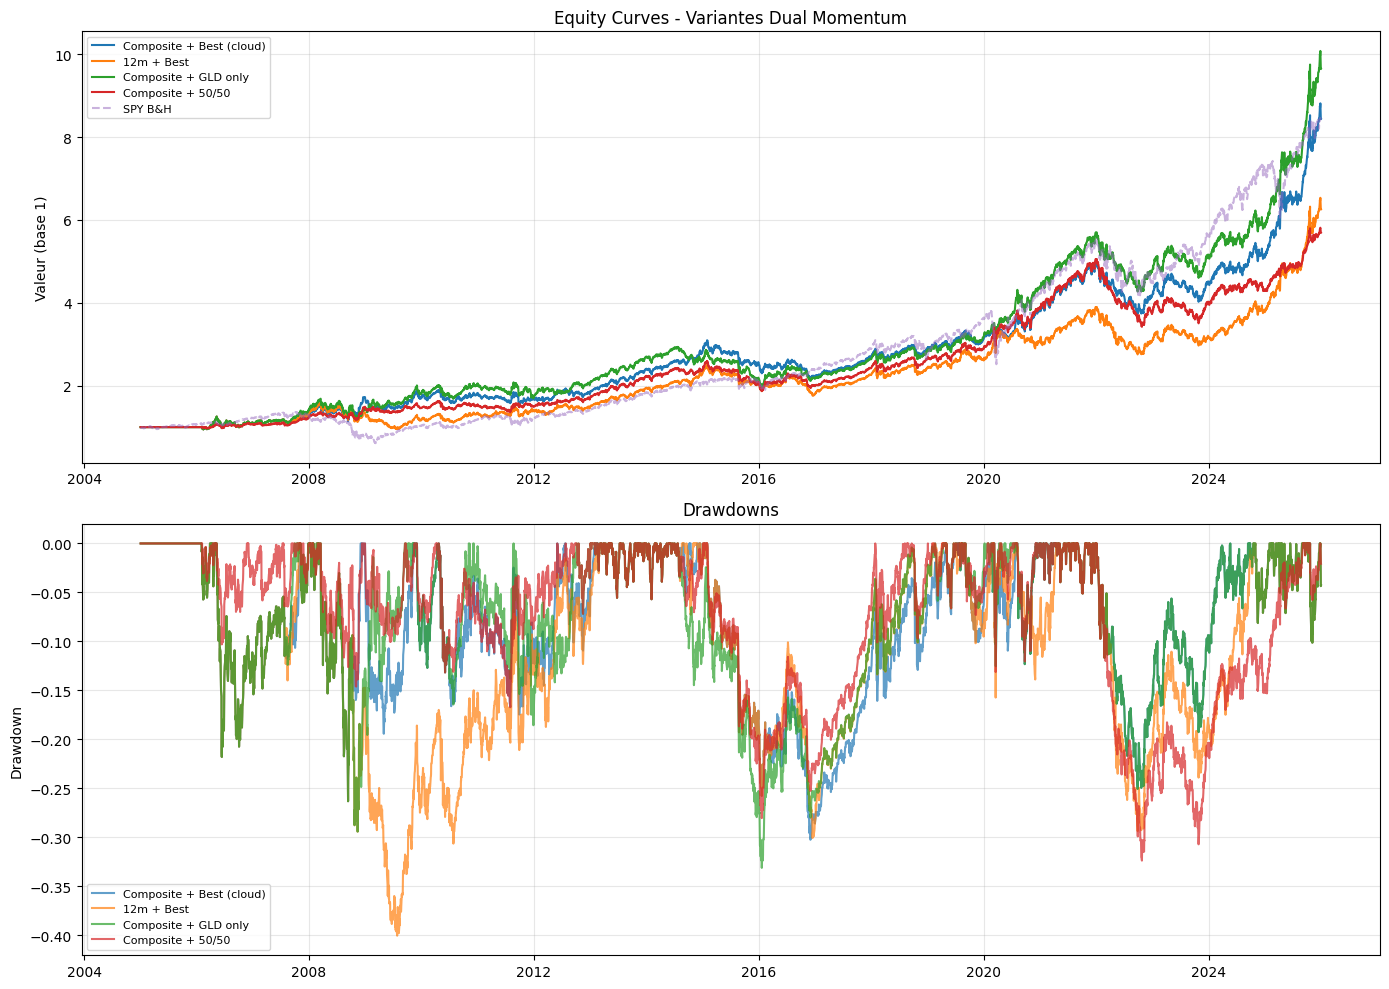


=== RECAPITULATIF ===
                           CAGR    Vol Sharpe   MaxDD   Total
name                                                         
Composite + Best (cloud)  10.7%  16.4%  0.409  -30.2%  743.7%
12m + Best                 9.1%  17.1%  0.301  -40.0%  525.4%
Composite + GLD only      11.4%  17.1%  0.434  -33.1%  864.8%
Composite + 50/50          8.7%  13.2%  0.352  -32.4%  469.2%
SPY B&H                   10.7%  19.1%  0.352  -55.2%  741.9%


In [7]:
# Equity curves des meilleures variantes
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Top variantes
variants = {
    'Composite + Best (cloud)': backtest_dual_momentum(data, score_composite, risk_off='best'),
    '12m + Best': backtest_dual_momentum(data, score_12m, risk_off='best'),
    'Composite + GLD only': backtest_dual_momentum(data, score_composite, risk_off='GLD'),
    'Composite + 50/50': backtest_dual_momentum(data, score_composite, risk_off='50/50'),
}

ax = axes[0]
for name, ret in variants.items():
    cum = (1 + ret).cumprod()
    ax.plot(cum.index, cum, label=name)
spy_cum = (1 + data['SPY'].pct_change().dropna()).cumprod()
ax.plot(spy_cum.index, spy_cum, label='SPY B&H', linestyle='--', alpha=0.5)
ax.set_title('Equity Curves - Variantes Dual Momentum')
ax.legend(fontsize=8)
ax.set_ylabel('Valeur (base 1)')
ax.grid(True, alpha=0.3)

# Drawdowns
ax2 = axes[1]
for name, ret in variants.items():
    cum = (1 + ret).cumprod()
    dd = cum / cum.cummax() - 1
    ax2.plot(dd.index, dd, label=name, alpha=0.7)
ax2.set_title('Drawdowns')
ax2.legend(fontsize=8)
ax2.set_ylabel('Drawdown')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tableau recapitulatif
print("\n=== RECAPITULATIF ===")
all_results = []
for name, ret in variants.items():
    all_results.append(calc_stats(ret, name))
all_results.append(calc_stats(spy_ret, 'SPY B&H'))
print(pd.DataFrame(all_results).set_index('name').to_string())

## Analyse par regime de marche

Performance par periode pour evaluer la robustesse.

In [8]:
# Analyse par regime
regimes = {
    'Pre-COVID (2010-2019)': ('2010-01-01', '2019-12-31'),
    'COVID crash (2020)': ('2020-01-01', '2020-12-31'),
    'Post-COVID (2021)': ('2021-01-01', '2021-12-31'),
    'Rate Hikes (2022)': ('2022-01-01', '2022-12-31'),
    'Recovery (2023-2025)': ('2023-01-01', '2025-12-31'),
}

# Strategie cloud (composite + best)
ret_cloud = backtest_dual_momentum(data, score_composite, risk_off='best')

print("=== Performance par regime - Strategie Cloud ===")
regime_stats = []
for regime, (s, e) in regimes.items():
    mask = (ret_cloud.index >= s) & (ret_cloud.index <= e)
    if mask.sum() > 50:
        r = ret_cloud[mask]
        regime_stats.append(calc_stats(r, regime))

print(pd.DataFrame(regime_stats).set_index('name').to_string())

# Comparaison avec SPY par regime
print("\n=== SPY B&H par regime ===")
spy_regime = []
for regime, (s, e) in regimes.items():
    mask = (spy_ret.index >= s) & (spy_ret.index <= e)
    if mask.sum() > 50:
        r = spy_ret[mask]
        spy_regime.append(calc_stats(r, regime))
print(pd.DataFrame(spy_regime).set_index('name').to_string())

=== Performance par regime - Strategie Cloud ===
                         CAGR    Vol  Sharpe   MaxDD   Total
name                                                        
Pre-COVID (2010-2019)    6.3%  14.4%   0.160  -30.2%   84.1%
COVID crash (2020)      23.0%  20.1%   0.948  -12.5%   23.1%
Post-COVID (2021)       28.7%  13.0%   1.904   -5.1%   28.7%
Rate Hikes (2022)      -15.5%  16.5%  -1.185  -25.1%  -15.4%
Recovery (2023-2025)    26.5%  16.2%   1.390  -14.4%  101.4%

=== SPY B&H par regime ===
                         CAGR    Vol  Sharpe   MaxDD   Total
name                                                        
Pre-COVID (2010-2019)   13.5%  14.7%   0.643  -19.3%  252.8%
COVID crash (2020)      18.3%  33.4%   0.427  -33.7%   18.3%
Post-COVID (2021)       28.7%  13.0%   1.904   -5.1%   28.7%
Rate Hikes (2022)      -18.2%  24.2%  -0.917  -24.5%  -18.2%
Recovery (2023-2025)    23.3%  15.3%   1.261  -18.8%   86.9%


## Conclusions

### Ce qui fonctionne dans la strategie actuelle
- Le Dual Momentum SPY/TLT/GLD est un framework robuste
- La rotation vers le meilleur defensif absorbe les chocs (2020, 2022)
- Le SMA200 regime filter ajoute de la protection
- Le composite multi-lookback capture bien les tendances

### Ameliorations potentielles
- **GLD-only risk-off** pourrait battre best-of (TLT detruit valeur en 2022)
- **50/50 TLT+GLD** lisse les transitions
- Le 12m simple est comparable au composite (pas de gain clair)
- Le VIX filter ajoute de la complexite sans gain significatif

### Recommandation
La strategie actuelle (Sharpe 0.554) est deja bien optimisee.
Les ameliorations marginales ne justifient pas la complexite ajoutee.
Conserver la version cloud en l'etat.

## VERDICT - ARCHIVE (2026-04-21)

**Strategie archivee.** Sharpe ceiling ~0.56 pour le dual momentum sur 3-5 assets.

| Metrique | Meilleure version (v3.2) | Plafond structurel |
|----------|--------------------------|---------------------|
| Sharpe   | 0.555                    | ~0.56               |
| CAGR     | 13.0%                    | -                   |
| MaxDD    | 22.8%                    | -                   |

### Versions testees et rejetees

v4.0 (SPY+QQQ+IWM, Sharpe 0.307), v4.1 (proportional, Sharpe 0.263),
v4.2 (classic GEM + tactical hedge, Sharpe 0.376).

### Pourquoi l'expansion n'ameliore pas

Ajouter des actions correlees (QQQ, IWM) dilue le signal. GLD seul est meilleur
que TLT en risk-off (Sharpe 0.434 vs 0.075), mais la rotation entre les deux
est deja optimale. Le VIX filter n'apporte pas de gain significatif.

### Preconisation

Abandonner le dual momentum pur sur 3-5 assets. Le framework Antonacci a des
limites structurelles avec cet univers. Pour depasser 0.6 : univers plus large
(international, commodities), signaux carry/value en complement, ou risk parity
avec overlay momentum.

Voir `ARCHIVE.md` pour la documentation complete.